<a href="https://colab.research.google.com/github/Athira-A-Ashok/MasterThesisExperiment/blob/master-thesis-dev/Master_Theseis_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Master Thesis Experimental Analysis**

**Title** : A Data-Driven Comparison of How Junior and Senior Developers Use Natural Language to Generate React Components

This notebook contains the statistical analysis, clustering analysis, visualisations, and metric evaluation used in the thesis experiment involving 150 software developers.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [ ]:
df = pd.read_csv('dataset.csv')
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head(10)

Dataset shape: (150, 13)

Columns: ['participant_id', 'experience_level', 'years_experience', 'prompt_length_chars', 'prompt_word_count', 'prompt_clarity', 'prompt_specificity', 'prompt_structure', 'ai_response_time_seconds', 'eslint_errors', 'cyclomatic_complexity', 'maintainability_index', 'readability_score']

First 5 rows:


,participant_id,experience_level,years_experience,prompt_length_chars,prompt_word_count,prompt_clarity,prompt_specificity,prompt_structure,ai_response_time_seconds,eslint_errors,cyclomatic_complexity,maintainability_index,readability_score
0,J1,junior,2.0,210,37,4,3,2,21.52,0,2.5,49.28,6.42
1,J2,junior,2.0,270,33,5,5,3,26.54,0,12.0,24.29,13.06
2,J3,junior,2.0,352,76,4,4,3,24.73,0,4.0,48.54,7.09
3,J4,junior,0.5,337,63,5,3,3,13.59,0,3.0,49.95,5.33
4,J5,junior,2.0,480,94,5,4,4,9.05,0,4.0,36.62,6.94
5,J6,junior,0.5,305,60,4,3,3,10.07,0,5.0,37.64,7.61
6,J7,junior,0.5,105,19,3,2,1,11.58,1,5.0,36.83,7.56
7,J8,junior,0.5,46,9,2,1,1,12.57,1,5.0,36.31,7.64
8,J9,junior,2.0,425,71,5,3,3,12.38,0,4.0,37.86,6.93
9,J10,junior,0.5,114,18,3,2,1,12.38,1,5.0,35.28,7.48


**Descriptive statistics - Overall Dataset**

In [ ]:
print("=" * 50)
print("DESCRIPTIVE STATISTICS - ALL PARTICIPANTS")
print("=" * 50)

numeric_cols = [
    'prompt_length_chars', 'prompt_word_count',
    'prompt_clarity', 'prompt_specificity', 'prompt_structure',
    'ai_response_time_seconds', 'eslint_errors',
    'cyclomatic_complexity', 'maintainability_index', 'readability_score'
]

df[numeric_cols].describe().round(2)

DESCRIPTIVE STATISTICS - ALL PARTICIPANTS


,prompt_length_chars,prompt_word_count,prompt_clarity,prompt_specificity,prompt_structure,ai_response_time_seconds,eslint_errors,cyclomatic_complexity,maintainability_index,readability_score
count,150.00,150.0,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00
mean,439.26,78.4,4.25,3.60,3.23,17.28,0.11,4.29,43.19,7.08
std,336.75,59.9,0.90,1.26,1.23,6.32,0.32,2.42,10.36,1.79
min,46.00,9.0,2.00,1.00,1.00,6.89,0.00,1.55,22.30,3.52
25%,176.50,34.0,3.00,2.00,2.00,12.96,0.00,2.67,36.78,5.93
50%,346.00,61.0,5.00,4.00,3.50,16.12,0.00,4.00,38.79,6.94
75%,574.50,97.0,5.00,5.00,4.00,19.09,0.00,5.00,51.34,7.50
max,1927.00,337.0,5.00,5.00,5.00,37.72,1.00,13.00,70.88,13.06


**Descriptive statistics by Experience Level**

In [ ]:
print("=" * 50)
print("STATISTICS BY EXPERIENCE LEVEL")
print("=" * 50)

grouped = df.groupby('experience_level')[numeric_cols].mean().round(2)
print(grouped)

STATISTICS BY EXPERIENCE LEVEL
                  prompt_length_chars  prompt_word_count  prompt_clarity  \
experience_level                                                           
junior                         202.21              37.96            3.52   
senior                         676.31             118.84            4.99   

                  prompt_specificity  prompt_structure  \
experience_level                                         
junior                          2.53              2.15   
senior                          4.67              4.31   

                  ai_response_time_seconds  eslint_errors  \
experience_level                                            
junior                               13.23           0.17   
senior                               21.32           0.05   

                  cyclomatic_complexity  maintainability_index  \
experience_level                                                 
junior                             4.70               

**Inferential Statistical Testing and Efficiency Metric**

EFFICIENCY METRIC BY EXPERIENCE LEVEL
experience_level
junior    3.01
senior    2.43
Name: efficiency_score, dtype: float64

STATISTICAL SIGNIFICANCE (T-TESTS)
                     Metric  T-Statistic       P-Value  Significant (p < 0.05)
0       prompt_length_chars     -12.1374  0.0000000000                    True
1         prompt_word_count     -11.2024  0.0000000000                    True
2            prompt_clarity     -17.3399  0.0000000000                    True
3        prompt_specificity     -19.6625  0.0000000000                    True
4          prompt_structure     -22.9103  0.0000000000                    True
5  ai_response_time_seconds     -10.1897  0.0000000000                    True
6             eslint_errors       2.3450  0.0206631032                    True
7     cyclomatic_complexity       2.1204  0.0360413097                    True
8     maintainability_index      -7.8732  0.0000000000                    True
9         readability_score       2.0690  0.040603

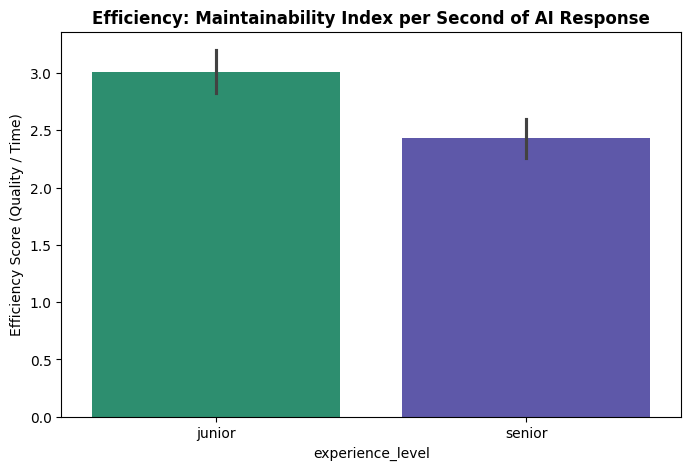

In [ ]:
from scipy import stats

# 1. Calculate Efficiency Metric (Maintainability produced per second of AI wait time)
df['efficiency_score'] = df['maintainability_index'] / df['ai_response_time_seconds']

print("=" * 50)
print("EFFICIENCY METRIC BY EXPERIENCE LEVEL")
print("=" * 50)
efficiency_grouped = df.groupby('experience_level')['efficiency_score'].mean().round(2)
print(efficiency_grouped)

# 2. Perform Statistical Significance Testing (Independent T-Tests)
junior_data = df[df['experience_level'] == 'junior']
senior_data = df[df['experience_level'] == 'senior']

# Key metrics for thesis hypothesis testing
metrics_to_test = ['prompt_length_chars', 'prompt_word_count',
                   'prompt_clarity', 'prompt_specificity', 'prompt_structure',
                   'ai_response_time_seconds', 'eslint_errors',
                   'cyclomatic_complexity', 'maintainability_index',
                   'readability_score']
ttest_results = []

for metric in metrics_to_test:
    t_stat, p_val = stats.ttest_ind(junior_data[metric], senior_data[metric], equal_var=False)
    ttest_results.append({
        'Metric': metric,
        'T-Statistic': round(t_stat, 4),
        'P-Value': format(p_val, '.10f'),
        'Significant (p < 0.05)': p_val < 0.05
    })

print("\n" + "=" * 50)
print("STATISTICAL SIGNIFICANCE (T-TESTS)")
print("=" * 50)
ttest_df = pd.DataFrame(ttest_results)
print(ttest_df)

# 3. Visualization for Efficiency
plt.figure(figsize=(8, 5))
sns.barplot(x='experience_level', y='efficiency_score', data=df, palette={'junior': '#1D9E75', 'senior': '#534AB7'})
plt.title('Efficiency: Maintainability Index per Second of AI Response', fontsize=12, fontweight='bold')
plt.ylabel('Efficiency Score (Quality / Time)')
plt.savefig('efficiency_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

**Effect Size Analysis (Cohen's d)**

In [ ]:
print("=" * 50)
print("COHEN'S D EFFECT SIZES")
print("=" * 50)

def cohens_d(a, b):
    pooled = np.sqrt(((len(a)-1)*a.std()**2 +
                      (len(b)-1)*b.std()**2) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / pooled

for metric in metrics_to_test:
    d = cohens_d(junior_data[metric], senior_data[metric])
    size = 'large' if abs(d)>=0.8 else ('medium' if abs(d)>=0.5 else 'small')
    print(f"{metric}: d = {d:.3f} ({size})")

COHEN'S D EFFECT SIZES
prompt_length_chars: d = -1.982 (large)
prompt_word_count: d = -1.829 (large)
prompt_clarity: d = -2.832 (large)
prompt_specificity: d = -3.211 (large)
prompt_structure: d = -3.741 (large)
ai_response_time_seconds: d = -1.664 (large)
eslint_errors: d = 0.383 (small)
cyclomatic_complexity: d = 0.346 (small)
maintainability_index: d = -1.286 (large)
readability_score: d = 0.338 (small)


**Assumption Verification - Shapiro-Wilk Normality test**

In [ ]:
print("=" * 50)
print("NORMALITY TEST - Shapiro-Wilk")
print("=" * 50)

from scipy.stats import shapiro

for metric in metrics_to_test:
    _, p_jr = shapiro(junior_data[metric])
    _, p_sr = shapiro(senior_data[metric])
    normal_jr = 'normal' if p_jr > 0.05 else 'NOT normal'
    normal_sr = 'normal' if p_sr > 0.05 else 'NOT normal'
    print(f"{metric}:")
    print(f"   Junior  p={p_jr:.4f} → {normal_jr}")
    print(f"   Senior  p={p_sr:.4f} → {normal_sr}")

NORMALITY TEST - Shapiro-Wilk
prompt_length_chars:
   Junior  p=0.0000 → NOT normal
   Senior  p=0.0000 → NOT normal
prompt_word_count:
   Junior  p=0.0000 → NOT normal
   Senior  p=0.0000 → NOT normal
prompt_clarity:
   Junior  p=0.0000 → NOT normal
   Senior  p=0.0000 → NOT normal
prompt_specificity:
   Junior  p=0.0000 → NOT normal
   Senior  p=0.0000 → NOT normal
prompt_structure:
   Junior  p=0.0000 → NOT normal
   Senior  p=0.0000 → NOT normal
ai_response_time_seconds:
   Junior  p=0.0002 → NOT normal
   Senior  p=0.0000 → NOT normal
eslint_errors:
   Junior  p=0.0000 → NOT normal
   Senior  p=0.0000 → NOT normal
cyclomatic_complexity:
   Junior  p=0.0000 → NOT normal
   Senior  p=0.0000 → NOT normal
maintainability_index:
   Junior  p=0.0000 → NOT normal
   Senior  p=0.0000 → NOT normal
readability_score:
   Junior  p=0.0000 → NOT normal
   Senior  p=0.0000 → NOT normal


**Prompt Quality Visualisation**

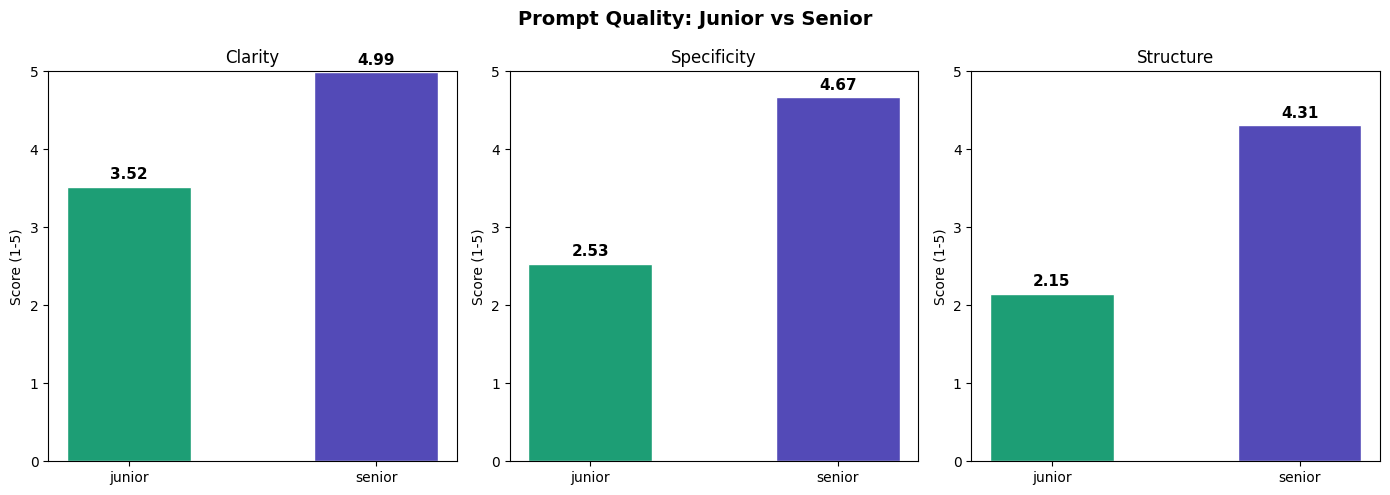

Saved: prompt_quality_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Prompt Quality: Junior vs Senior', fontsize=14, fontweight='bold')

prompt_metrics = ['prompt_clarity', 'prompt_specificity', 'prompt_structure']
titles = ['Clarity', 'Specificity', 'Structure']
colors = {'junior': '#1D9E75', 'senior': '#534AB7'}

for i, (metric, title) in enumerate(zip(prompt_metrics, titles)):
    means = df.groupby('experience_level')[metric].mean()
    bars = axes[i].bar(means.index, means.values,
                       color=[colors[x] for x in means.index],
                       edgecolor='white', width=0.5)
    axes[i].set_title(title, fontsize=12)
    axes[i].set_ylim(0, 5)
    axes[i].set_ylabel('Score (1-5)')
    for bar, val in zip(bars, means.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.1,
                     f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('prompt_quality_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: prompt_quality_comparison.png")

**Code Quality Visualisation**

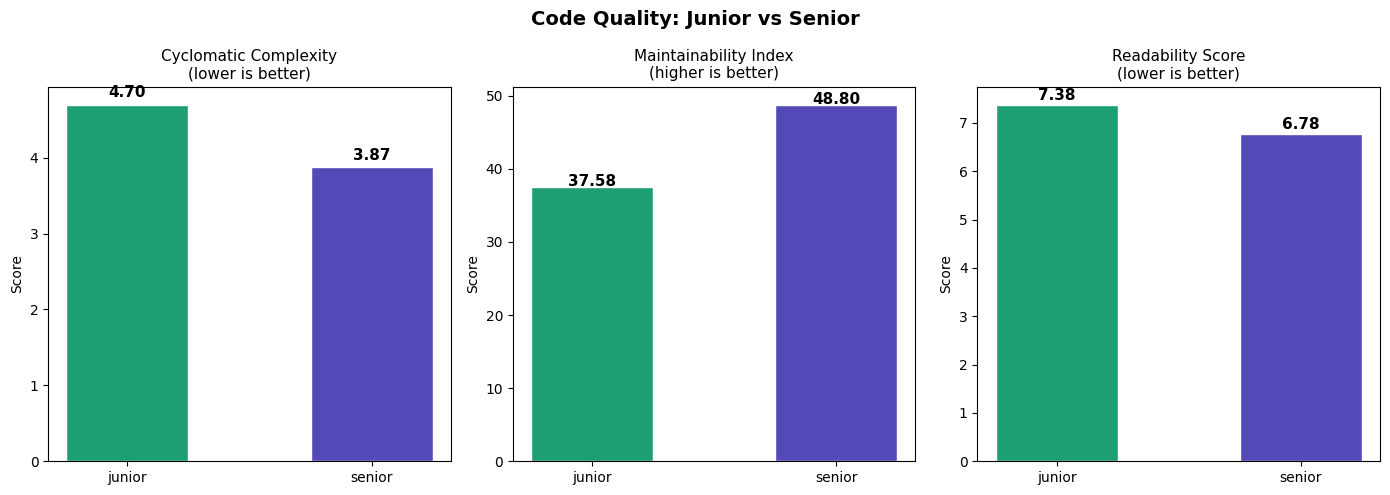

Saved: code_quality_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Code Quality: Junior vs Senior', fontsize=14, fontweight='bold')

code_metrics = ['cyclomatic_complexity', 'maintainability_index', 'readability_score']
titles = ['Cyclomatic Complexity\n(lower is better)',
          'Maintainability Index\n(higher is better)',
          'Readability Score\n(lower is better)']

for i, (metric, title) in enumerate(zip(code_metrics, titles)):
    means = df.groupby('experience_level')[metric].mean()
    bars = axes[i].bar(means.index, means.values,
                       color=[colors[x] for x in means.index],
                       edgecolor='white', width=0.5)
    axes[i].set_title(title, fontsize=11)
    axes[i].set_ylabel('Score')
    for bar, val in zip(bars, means.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.1,
                     f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('code_quality_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: code_quality_comparison.png")

**AI Response Time and Prompt Length Analysis**

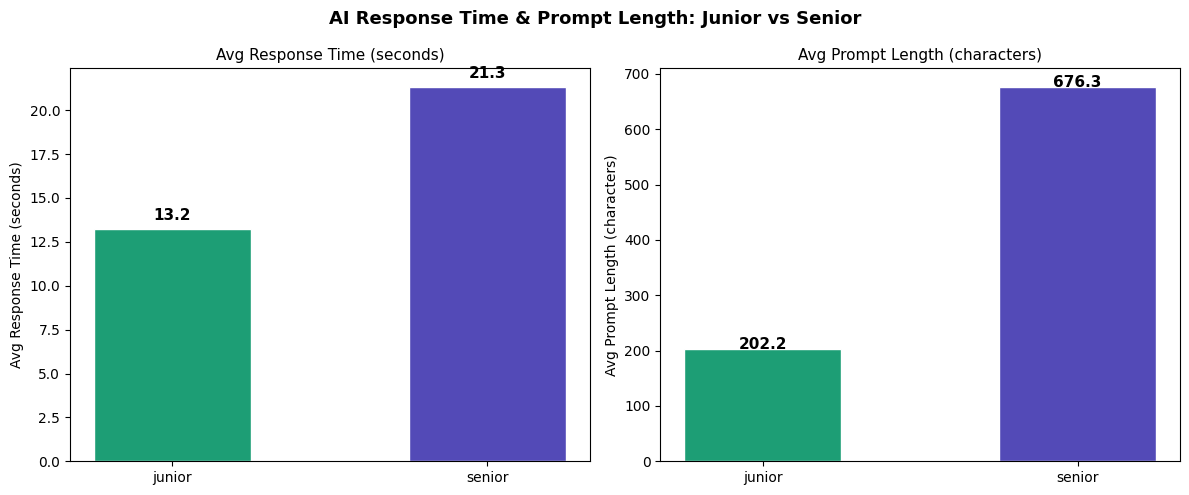

Saved: response_time_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('AI Response Time & Prompt Length: Junior vs Senior',
             fontsize=13, fontweight='bold')

for i, (metric, title) in enumerate(zip(
    ['ai_response_time_seconds', 'prompt_length_chars'],
    ['Avg Response Time (seconds)', 'Avg Prompt Length (characters)']
)):
    means = df.groupby('experience_level')[metric].mean()
    bars = axes[i].bar(means.index, means.values,
                       color=[colors[x] for x in means.index],
                       edgecolor='white', width=0.5)
    axes[i].set_title(title, fontsize=11)
    axes[i].set_ylabel(title)
    for bar, val in zip(bars, means.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('response_time_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: response_time_comparison.png")

**Correlation Analysis**

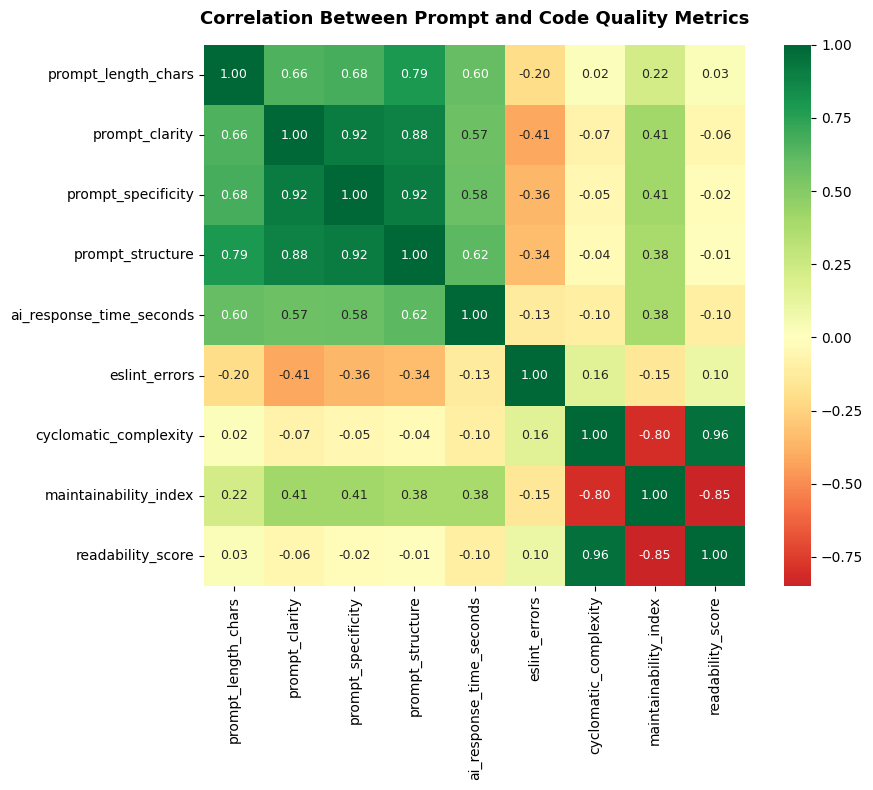

Saved: correlation_heatmap.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

corr_cols = [
    'prompt_length_chars', 'prompt_clarity', 'prompt_specificity',
    'prompt_structure', 'ai_response_time_seconds', 'eslint_errors',
    'cyclomatic_complexity', 'maintainability_index', 'readability_score'
]

corr_matrix = df[corr_cols].corr().round(2)

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, square=True,
            annot_kws={'size': 9})

ax.set_title('Correlation Between Prompt and Code Quality Metrics',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: correlation_heatmap.png")

**K-means Clustering Analysis**

In [ ]:
print("=" * 50)
print("K-MEANS CLUSTERING ANALYSIS")
print("=" * 50)

# Features for clustering
cluster_features = [
    'prompt_length_chars', 'prompt_clarity', 'prompt_specificity',
    'prompt_structure', 'cyclomatic_complexity',
    'maintainability_index', 'readability_score'
]

X = df[cluster_features].copy()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-means with k=2 (junior vs senior)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("\nCluster assignment vs actual experience level:")
print(df[['participant_id', 'experience_level', 'cluster']].to_string(index=False))

print("\nCluster distribution:")
print(df.groupby(['experience_level', 'cluster']).size().reset_index(name='count'))

K-MEANS CLUSTERING ANALYSIS

Cluster assignment vs actual experience level:
participant_id experience_level  cluster
            J1           junior        0
            J2           junior        0
            J3           junior        0
            J4           junior        1
            J5           junior        1
            J6           junior        0
            J7           junior        0
            J8           junior        0
            J9           junior        0
           J10           junior        0
           J11           junior        0
           J12           junior        0
           J13           junior        0
           J14           junior        0
           J15           junior        0
           J16           junior        0
           J17           junior        0
           J18           junior        0
           J19           junior        0
           J20           junior        0
           J21           junior        0
           J22        

**Cluster Validation - Silhouette score**

In [ ]:
print("=" * 50)
print("CLUSTER VALIDATION - Silhouette Score")
print("=" * 50)

from sklearn.metrics import silhouette_score

sil = silhouette_score(X_scaled, df['cluster'])
print(f"Silhouette Score (k=2): {sil:.4f}")

if sil >= 0.5:
    print("Interpretation: Strong cluster separation")
elif sil >= 0.25:
    print("Interpretation: Reasonable cluster separation")
else:
    print("Interpretation: Weak cluster separation")

CLUSTER VALIDATION - Silhouette Score
Silhouette Score (k=2): 0.4781
Interpretation: Reasonable cluster separation


**Cluster Validation - Elbow Method**

ELBOW METHOD - Optimal k
k=2: inertia=574.67
k=3: inertia=276.69
k=4: inertia=235.83
k=5: inertia=196.51
k=6: inertia=173.87
k=7: inertia=158.77


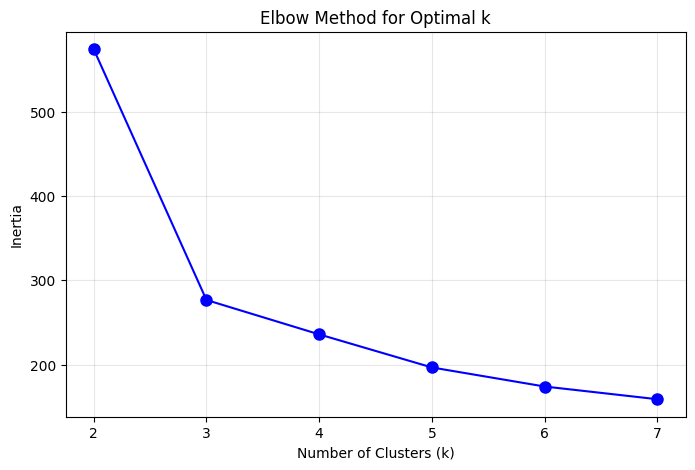

Saved: elbow_method.png


In [ ]:
print("=" * 50)
print("ELBOW METHOD - Optimal k")
print("=" * 50)

inertias = []
k_values = range(2, 8)

for k in k_values:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_temp.fit(X_scaled)
    inertias.append(km_temp.inertia_)
    print(f"k={k}: inertia={km_temp.inertia_:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True, alpha=0.3)
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: elbow_method.png")

**Clustering visualisation**

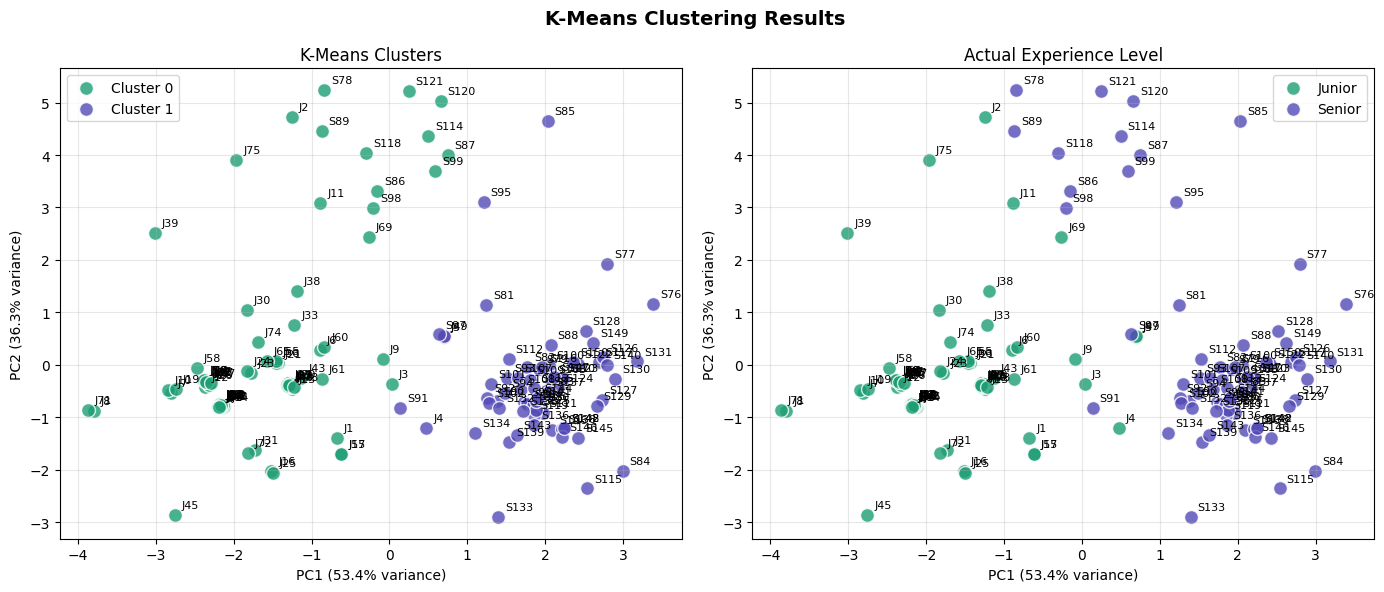

Saved: clustering_visualization.png


In [ ]:
# PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('K-Means Clustering Results', fontsize=14, fontweight='bold')

# Plot 1 — by cluster
cluster_colors = {0: '#1D9E75', 1: '#534AB7'}
for cluster_id in [0, 1]:
    mask = df['cluster'] == cluster_id
    axes[0].scatter(df[mask]['pca1'], df[mask]['pca2'],
                    c=cluster_colors[cluster_id],
                    label=f'Cluster {cluster_id}',
                    s=100, alpha=0.8, edgecolors='white')
    for _, row in df[mask].iterrows():
        axes[0].annotate(row['participant_id'],
                         (row['pca1'], row['pca2']),
                         textcoords='offset points',
                         xytext=(5, 5), fontsize=8)

axes[0].set_title('K-Means Clusters', fontsize=12)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 — by actual experience level
exp_colors = {'junior': '#1D9E75', 'senior': '#534AB7'}
for level in ['junior', 'senior']:
    mask = df['experience_level'] == level
    axes[1].scatter(df[mask]['pca1'], df[mask]['pca2'],
                    c=exp_colors[level],
                    label=level.capitalize(),
                    s=100, alpha=0.8, edgecolors='white')
    for _, row in df[mask].iterrows():
        axes[1].annotate(row['participant_id'],
                         (row['pca1'], row['pca2']),
                         textcoords='offset points',
                         xytext=(5, 5), fontsize=8)

axes[1].set_title('Actual Experience Level', fontsize=12)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('clustering_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: clustering_visualization.png")